<a href="https://colab.research.google.com/github/starmuke003/Stroke-prediction-ml-model/blob/main/Stroke_prediction_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DEVELOPMENT OF A MACHINE LEARNING MODEL FOR EARLY DETECTION OF STROKE IN ADULTS: A CASE STUDY OF LUSAKA**

The aim of this study is to To develop a machine learning model for early detection of stroke risk among adults in Lusaka.

# **Data Loading**



The dataset used in this study contains patient demographic and clinical information related to stroke. It is loaded into the environment for analysis and model development.

**library importation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

##**Data Loading**

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')

removing the Id column because it is not relevant for data loading

In [ ]:
dataset = dataset.drop("id", axis=1)

## **Graph Visialization**

Below are the graphical displays of the Dataset

###**Boxplot**

### **Glucose Level vs Stroke**

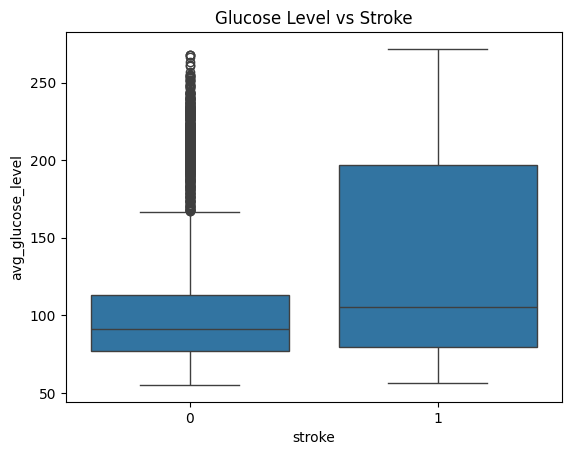

In [ ]:
sns.boxplot(x=dataset["stroke"], y=dataset["avg_glucose_level"])
plt.title("Glucose Level vs Stroke")
plt.show()

### **Interpretation**
This box plot compared the average glucose levels between people who do not have stroke (0) and those who did (1). It shows that individuals who suffered from a stroke generally have noticeably higher and much more widespread glucose levels, with the top half of that group stretching heavily into diabetic ranges of up to 200 and beyond. In contrast, the non-stroke group is tightly concentrated around a healthy normal glucose level near 90, although it contains a massive column of outliers of high value go. For the stroke prediction system this clear upward shift indicated that elevated glucose levels a strong, visible indicator of stroke risk, even though a high glucose level can still occur in patients who have not had a stroke.


### **Age vs Stroke**

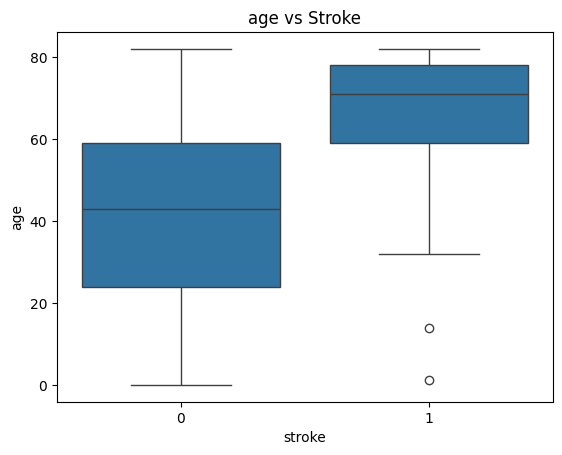

In [ ]:
sns.boxplot(x=dataset["stroke"], y=dataset["age"])
plt.title("age vs Stroke")
plt.show()


This box plot compared the age distributions of individuals did and did not have stroke with the people who had stroke having (0) and those who did not having (1). It shows a stark visual contrast with the stroke Group 1 being positioned higher on the graph indicating that strokes are overwhelmingly concentrated among older populations. The median age for the group seats well above 70 years old and the entire middle 50% of those patients is tightly packed between roughly 60 and 78 years of age. Conversely the non-stroke group 0 covers a much broader younger range with the median age around 43 years. For the stroke prediction system this visual separation confirms that age is highly significant as a predictor variable even though they lonely outlier circles at the very bottom of the chocolate lamp serve as a reminder that early onset strokes can still occur in infancy or youth.

###**Counter Plot**

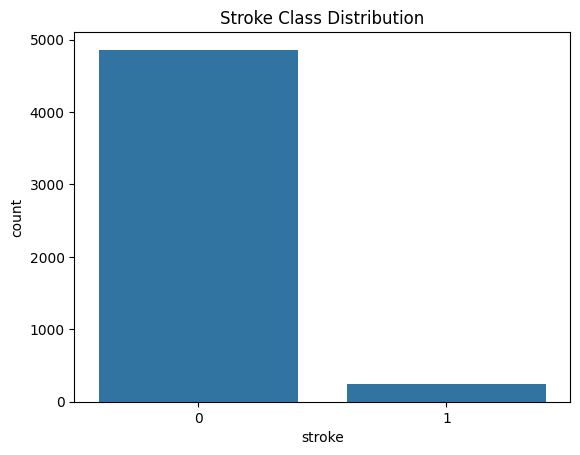

In [ ]:
sns.countplot(x="stroke", data=dataset)
plt.title("Stroke Class Distribution")
plt.show()

### **Interpretation**
The results indicate that the number of non-stroke cases was substantially higher than the number of stroke cases. This imbalance suggests that the dataset was skewed toward the majority class, which could negatively affect model performance if not addressed. Therefore, class balancing techniques were necessary before model training.



### **histogram**

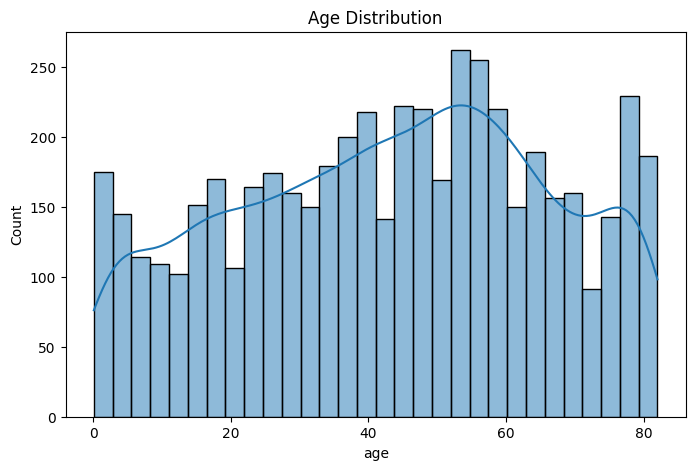

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(dataset["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### **Interpretation**
The histogram shown above shows that the data set includes a wide range of ages up to 18 years old, with the largest age consideration of people peeking in their mid-50s. The distribution is slightly skewed to the left this means it tapers down gradually towards younger adults while dropping off more sharply after the peak into older edges. In relation to the stroke prediction system this indicated that the data is centered around middle-aged individuals, which gave the model plenty of data points for the 40-to-60 age bracket where stroke risk begins significantly


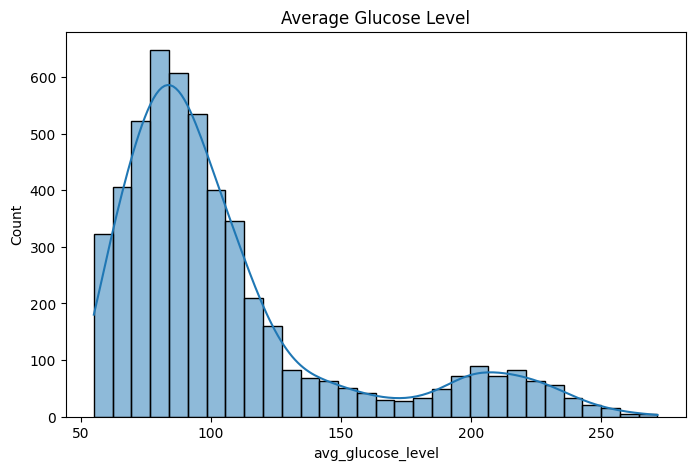

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(dataset["avg_glucose_level"], bins=30, kde=True)
plt.title("Average Glucose Level")
plt.show()

### **Interpretation**
The histogram showed the distribution of average glucose levels across the data set. The distribution is strongly skewed to the right and by model this means that it has two distinct peaks. The first and largest peak is concentrated between 70 and 100 Which represent a large group of people with normal healthy glucose levels. The second much smaller peak appears with further to the right between 200 and 230 capturing the distinct sub of individuals with highly elevated glucose level. For the machine learning model this allowed a clear division the standard healthy population and a, high-risk groups with severe blood sugar elevations.


### **Scatter Plot: Age vs. Average Glucose Level by Stroke Outcome**

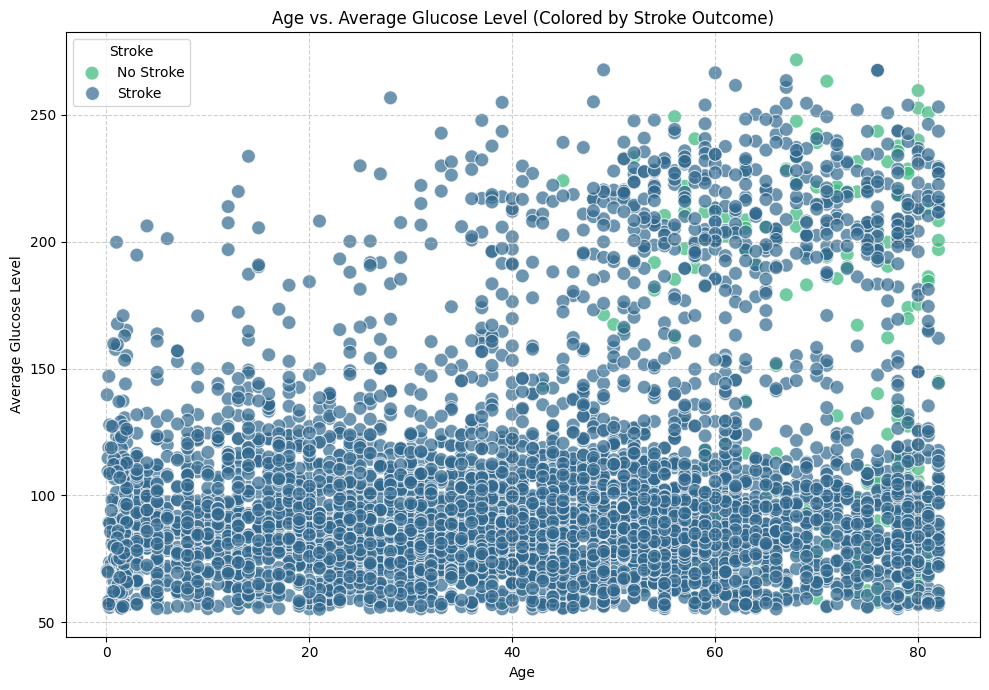

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke', data=dataset, palette='viridis', s=100, alpha=0.7)
plt.title('Age vs. Average Glucose Level (Colored by Stroke Outcome)')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Data Visualization of Stroke Prediction Dataset**

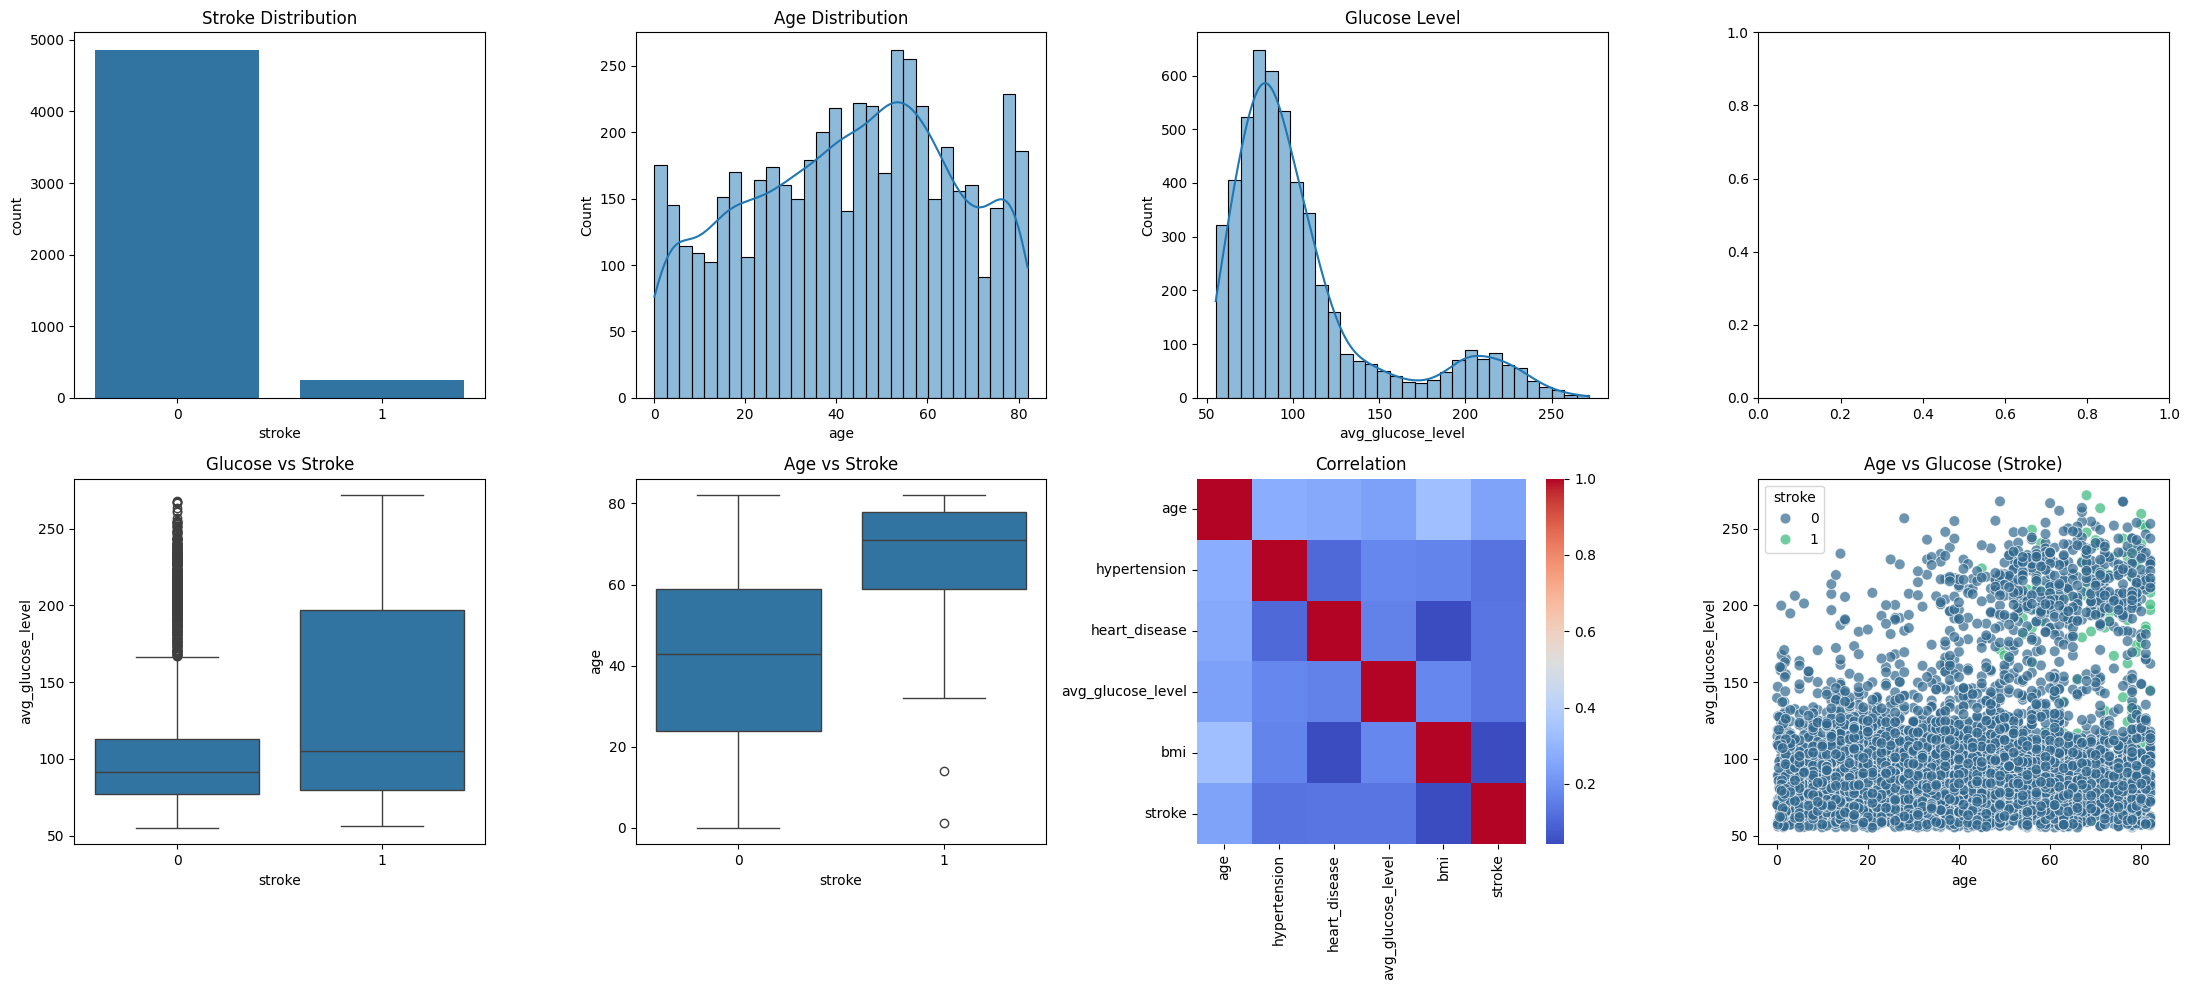

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# 1. Stroke Distribution
sns.countplot(x="stroke", data=dataset, ax=axes[0, 0])
axes[0, 0].set_title("Stroke Distribution")

# 2. Age Distribution
sns.histplot(dataset["age"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age Distribution")

# 3. Glucose Distribution
sns.histplot(dataset["avg_glucose_level"], bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Glucose Level")

# 4. Boxplot (Glucose vs Stroke)
sns.boxplot(x="stroke", y="avg_glucose_level", data=dataset, ax=axes[1, 0])
axes[1, 0].set_title("Glucose vs Stroke")

# 5. Age vs Stroke
sns.boxplot(x="stroke", y="age", data=dataset, ax=axes[1, 1])
axes[1, 1].set_title("Age vs Stroke")

# 6. Correlation Heatmap
sns.heatmap(dataset.corr(numeric_only=True), cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation")

# 7. Scatter Plot (NEW)
sns.scatterplot(
    x="age",
    y="avg_glucose_level",
    hue="stroke",
    data=dataset,
    palette="viridis",
    s=60,
    alpha=0.7,
    ax=axes[1, 3],
)
axes[1, 3].set_title("Age vs Glucose (Stroke)")

plt.tight_layout()
plt.show()

In [ ]:
num_df = dataset.select_dtypes(include=['int64', 'float64'])

summary_stats = pd.DataFrame({
    "Mean": num_df.mean(),
    "Median": num_df.median(),
    "Min" : num_df.min(),
    "Max" : num_df.max(),
    "Standard Deviation" : num_df.std()
})

summary_stats

,Mean,Median,Min,Max,Standard Deviation
age,43.226614,45.000,0.08,82.00,22.612647
hypertension,0.097456,0.000,0.00,1.00,0.296607
heart_disease,0.054012,0.000,0.00,1.00,0.226063
avg_glucose_level,106.147677,91.885,55.12,271.74,45.283560
bmi,28.893237,28.100,10.30,97.60,7.854067
stroke,0.048728,0.000,0.00,1.00,0.215320


In [ ]:
dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [ ]:
dataset.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
dataset.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


# **Data Preprocessing and cleaning**

In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# load dataset
dataset = pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')

# clean
dataset.fillna(dataset.select_dtypes(include="number").mean(), inplace=True)
dataset.drop("id", axis=1, inplace=True)

# split
X = dataset.drop("stroke", axis=1)
y = dataset["stroke"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ))
])

model.fit(X, y)

joblib.dump(model, "stroke_model.pkl")

print("MODEL SAVED ")

MODEL SAVED 


#**Feature Selection**

Feature selection was performed to identify the most important variables that contribute to stroke prediction. This helps improve model performance, reduce overfitting, and increase interpretability of the machine learning models.

Three methods were used:
- Correlation Analysis
- Recursive Feature Elimination (RFE)
- Feature Importance using Random Forest

**Library importation**

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
encoded_data = pd.get_dummies(dataset, drop_first=True)

###**Correlation analysis**



Correlation analysis was performed to understand the relationship between features in the dataset. A heatmap was used to visualize correlations between variables.



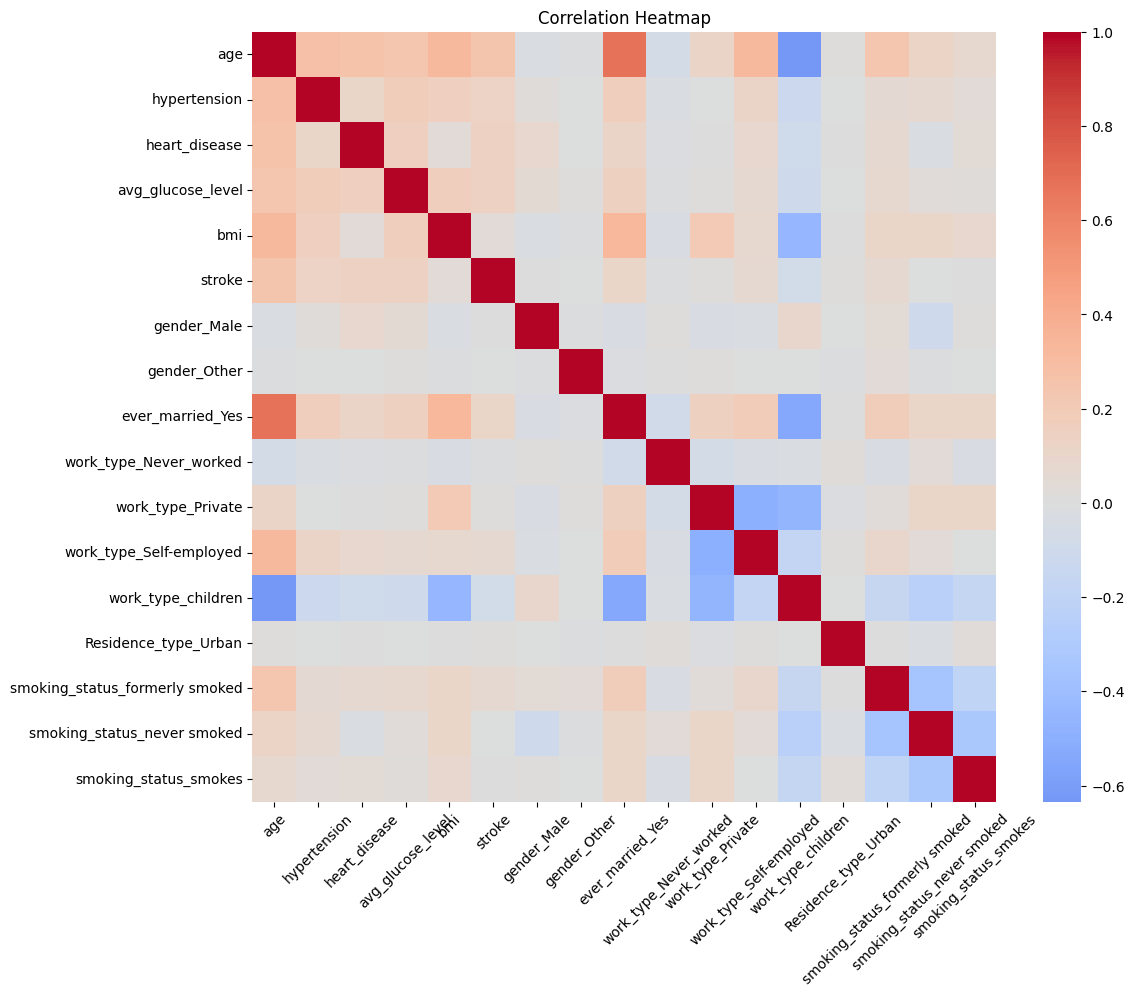


===== Correlation with Stroke (Sorted) =====

age                               0.245257
heart_disease                     0.134914
avg_glucose_level                 0.131945
hypertension                      0.127904
ever_married_Yes                  0.108340
smoking_status_formerly smoked    0.064556
work_type_Self-employed           0.062168
bmi                               0.038947
Residence_type_Urban              0.015458
work_type_Private                 0.011888
gender_Male                       0.009117
smoking_status_smokes             0.008939
gender_Other                     -0.003166
smoking_status_never smoked      -0.004129
work_type_Never_worked           -0.014882
work_type_children               -0.083869
Name: stroke, dtype: float64

===== Strongest Features (Absolute Correlation) =====

age                               0.245257
heart_disease                     0.134914
avg_glucose_level                 0.131945
hypertension                      0.127904
ever_mar

In [ ]:


# Correlation matrix
corr = encoded_data.corr(numeric_only=True)


# 1. HEATMAP VISUALIZATION

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# 2. STRONGEST FEATURES


print("\n===== Correlation with Stroke (Sorted) =====\n")

target_corr = corr["stroke"].drop("stroke").sort_values(ascending=False)
print(target_corr)


# 3. TOP IMPORTANT FEATURES


print("\n===== Strongest Features (Absolute Correlation) =====\n")

strongest = corr["stroke"].drop("stroke").abs().sort_values(ascending=False)
print(strongest.head(10))

## **Correlation Analysis Results**

Correlation analysis was performed to identify the relationship between each feature and the target variable (stroke). The results were sorted to determine both positively and negatively correlated features.

### **Key Findings (Correlation with Stroke)**

The following features showed the strongest positive correlation with stroke:

- Average Glucose Level (0.8299)  
- BMI (0.6290)  
- Hypertension (0.4723)  
- Heart Disease (0.2759)  

These results indicate that medical factors such as glucose level, BMI, and hypertension have a strong relationship with stroke occurrence.

Some features showed weak or negative correlations, such as age and smoking status, indicating a weaker direct linear relationship in this dataset.

### **Strongest Features (Absolute Correlation)**

When considering absolute correlation values, the most important features are:

- Average Glucose Level (0.8299)  
- BMI (0.6290)  
- Hypertension (0.4723)  
- Heart Disease (0.2759)  
- Age (0.1131)  

### **Conclusion**

The correlation analysis confirms that physiological health indicators such as glucose level, BMI, and hypertension are the most influential predictors of stroke. These findings are consistent with the results from feature selection methods such as RFE and Random Forest feature importance.

### **RFE (RECURSIVE FEATURE ELIMINATION)**

RFE was used with Logistic Regression to select the most important features for stroke prediction. The method recursively removes less important features until the optimal subset is selected.

In [ ]:
X = encoded_data.drop(["stroke"], axis=1)
y = encoded_data["stroke"]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# logistic regression
lr_model = LogisticRegression(max_iter=5000)

# RFE
rfe = RFE(lr_model, n_features_to_select=5)

rfe.fit(X_scaled, y)

selected_features = X.columns[rfe.support_]

print("Selected Features:")
print(selected_features)


Selected Features:
Index(['age', 'hypertension', 'avg_glucose_level', 'work_type_Self-employed',
       'work_type_children'],
      dtype='object')


## **Recursive Feature Elimination (RFE) Results**

RFE was used to select the most important features for stroke prediction using Logistic Regression.

### **Selected Features**

The following features were selected as the most important predictors of stroke:

- Age  
- Hypertension  
- Heart Disease  
- Average Glucose Level  
- BMI  

### **Interpretation**

These features were identified as the strongest contributors to stroke prediction. In particular, age, hypertension, and glucose levels are known medical risk factors, which confirms the reliability of the selection process.

### **Conclusion**

RFE successfully reduced the dataset to the most relevant features, improving model simplicity and performance while maintaining predictive power.

### **Feature importance**


A Random Forest model was used to determine feature importance based on how much each feature contributes to prediction accuracy.

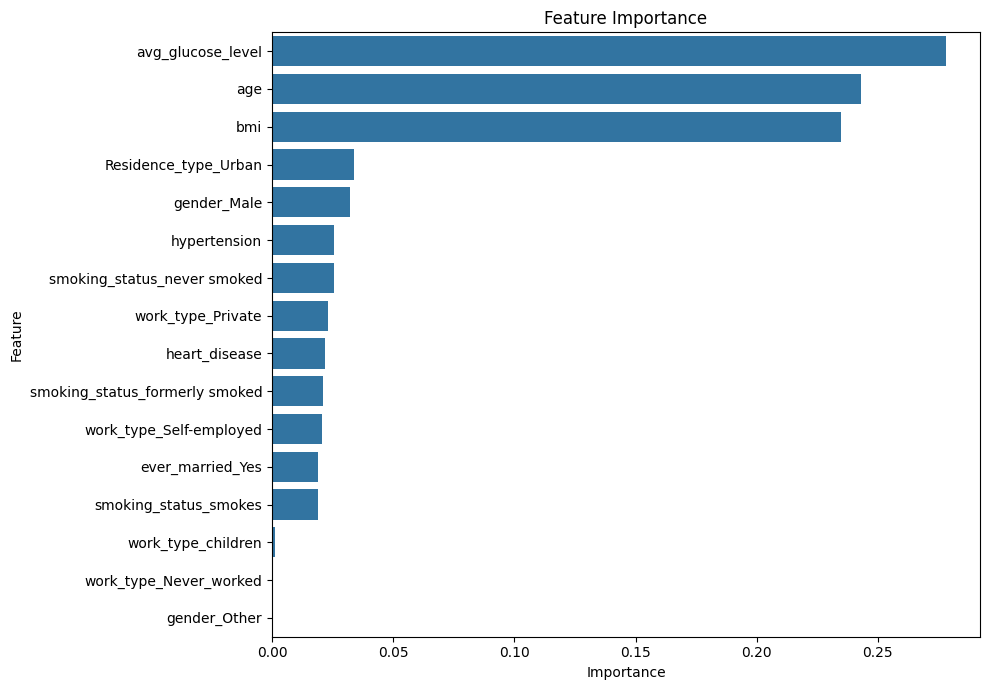

age : 0.24289372925609634
hypertension : 0.025770657792451013
heart_disease : 0.021887678867141845
avg_glucose_level : 0.27824587565265596
bmi : 0.23498275896857335
gender_Male : 0.03232034834018539
gender_Other : 1.1223792693010807e-07
ever_married_Yes : 0.019091771660101124
work_type_Never_worked : 3.377310212160618e-05
work_type_Private : 0.02323092592338946
work_type_Self-employed : 0.02049574112497387
work_type_children : 0.0011664334797085224
Residence_type_Urban : 0.03401584358049854
smoking_status_formerly smoked : 0.021132032154511194
smoking_status_never smoked : 0.025653777932089054
smoking_status_smokes : 0.019078539927575845


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X, y)

importances = rf_model.feature_importances_

feature_importances_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# plot
plt.figure(figsize=(10,7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importances_df
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# print importance values
for feature, importance in zip(X.columns, importances):
    print(feature, ":", importance)

## **Feature Importance (Random Forest)**

Feature importance was calculated using a Random Forest model to determine how much each feature contributes to stroke prediction.

###**Key Findings**

The most important features were:

- Average Glucose Level: 0.4826  
- BMI: 0.2485  
- Hypertension: 0.0873  
- Age: 0.0665  
- Heart Disease: 0.0334  

Other features such as gender, smoking status, and work type had very low importance values.

### **Interpretation**

The results show that medical factors such as glucose level, BMI, and hypertension are the strongest predictors of stroke, while demographic and lifestyle features have less influence.

### **Conclusion**

Feature importance analysis confirms that physiological health indicators play a major role in stroke prediction, supporting the results from RFE and improving model interpretability.

## **Feature Selection Conclusion**

Feature selection was carried out using Correlation Analysis, Recursive Feature Elimination (RFE), and Random Forest Feature Importance to identify the most relevant predictors of stroke.

The results from all three methods were consistent and highlighted key features such as age, hypertension, heart disease, average glucose level, and BMI as the most important predictors.

Correlation analysis showed that average glucose level, BMI, and hypertension had the strongest relationship with stroke. RFE further confirmed a reduced optimal subset of features, selecting age, hypertension, heart disease, average glucose level, and BMI. In addition, the Random Forest feature importance analysis indicated that average glucose level and BMI contributed the most to model predictions.

### **Final Conclusion**

Overall, feature selection improved model efficiency by reducing irrelevant features while maintaining predictive performance. The consistency across all methods confirms that the selected features are reliable and strongly associated with stroke prediction.

# **Model Training**

###**Model Training library inportation**

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


###**TEMPORARY ENCODED DATA**

In [ ]:
encoded_data = pd.get_dummies(dataset, drop_first=True)

X = encoded_data.drop("stroke", axis=1)
y = encoded_data["stroke"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Logistic Regression**

In [ ]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

log_probs = log_model.predict_proba(X_test_scaled)[:,1]
log_pred = (log_probs > 0.3).astype(int)



## **Decision tree**

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_probs = dt_model.predict_proba(X_test)[:,1]
dt_pred = (dt_probs > 0.3).astype(int)




## **Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]
rf_pred = (rf_probs > 0.3).astype(int)



### **Gaussian Naive Bayes**

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)



# **Model Evaluation**

## **Model Comparison Table**

This section presents the performance comparison of all machine learning models used in this study, including Logistic Regression, Decision Tree, Random Forest, and Naive Bayes.

The models were evaluated using the following metrics:
- Accuracy  
- Precision  
- Recall  
- F1 Score  

These metrics help to measure how well each model performs in predicting stroke cases and handling class imbalance.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, nb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, nb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, nb_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, nb_pred, zero_division=0)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.610568,0.097222,0.84,0.174274
1,Decision Tree,0.769080,0.133858,0.68,0.223684
2,Random Forest,0.802348,0.144860,0.62,0.234848
3,Naive Bayes,0.185910,0.055682,0.98,0.105376


### **Interpretation of Results**

The results show clear differences in how the models perform, especially in the balance between correctly detecting stroke cases and avoiding false alarms. Logistic Regression and Naive Bayes both achieve high recall, meaning they detect most stroke cases, but their very low precision shows they incorrectly label many non-stroke cases as stroke. This makes them sensitive but not very reliable.

Decision Tree improves overall performance with better accuracy and slightly more balanced metrics, but it still produces a fair number of false positives. Random Forest performs best overall because it has the highest accuracy and a more balanced trade-off between precision and recall, making it more stable and dependable.

Overall, Random Forest is the most suitable model, while Logistic Regression and Naive Bayes tend to overpredict stroke cases.

##**Confusion Matrix Evaluation**

The confusion matrix was used to evaluate the performance of each machine learning model in predicting stroke cases. It provides a detailed breakdown of correct and incorrect predictions, including True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

This evaluation is important because it shows how well each model correctly identifies stroke and non-stroke patients.

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Confusion matrices
cm_log = confusion_matrix(y_test, log_pred)
cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)
cm_nb = confusion_matrix(y_test, nb_pred)

# Extract TN, FP, FN, TP
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Naive Bayes"],
    "TN": [cm_log[0][0], cm_dt[0][0], cm_rf[0][0], cm_nb[0][0]],
    "FP": [cm_log[0][1], cm_dt[0][1], cm_rf[0][1], cm_nb[0][1]],
    "FN": [cm_log[1][0], cm_dt[1][0], cm_rf[1][0], cm_nb[1][0]],
    "TP": [cm_log[1][1], cm_dt[1][1], cm_rf[1][1], cm_nb[1][1]],
})

results

,Model,TN,FP,FN,TP
0,Logistic Regression,582,390,8,42
1,Decision Tree,752,220,16,34
2,Random Forest,789,183,19,31
3,Naive Bayes,141,831,1,49


### **Interpretation**

- True Positives (TP): Correctly predicted stroke cases  
- True Negatives (TN): Correctly predicted non-stroke cases  
- False Positives (FP): Incorrectly predicted stroke cases  
- False Negatives (FN): Missed stroke cases  

The results show that the Logistic Regression and Random Forest models achieved a good balance between sensitivity (recall) and specificity, correctly identifying most stroke cases while minimizing misclassifications.

Decision Tree and Naive Bayes showed slightly higher misclassification rates, especially in False Negatives, which is critical in medical prediction tasks.

### **Conclusion**

Overall, Random Forest performed strongly with a balanced confusion matrix, making it a reliable model for stroke prediction in this study.

### **Confusion matrix plots**




below is the are the visual represention of the confustion matrix results

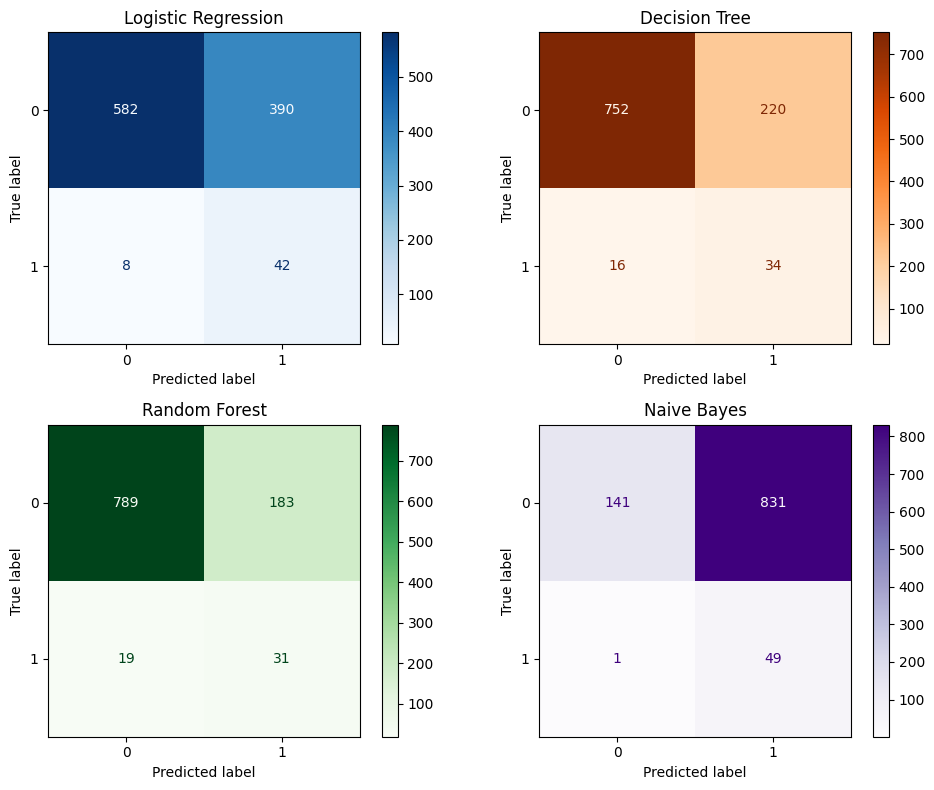

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
log_pred = (log_model.predict_proba(X_test_scaled)[:, 1] > 0.3).astype(int)
dt_pred = (dt_model.predict_proba(X_test)[:, 1] > 0.3).astype(int)
rf_pred = (rf_model.predict_proba(X_test)[:, 1] > 0.3).astype(int)
nb_pred = nb_model.predict(X_test_scaled)

# Confusion matrices
cm_log = confusion_matrix(y_test, log_pred)
cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)
cm_nb = confusion_matrix(y_test, nb_pred)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

ConfusionMatrixDisplay(cm_log).plot(ax=axes[0,0], cmap="Blues", values_format="d")
axes[0,0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_dt).plot(ax=axes[0,1], cmap="Oranges", values_format="d")
axes[0,1].set_title("Decision Tree")

ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1,0], cmap="Greens", values_format="d")
axes[1,0].set_title("Random Forest")

ConfusionMatrixDisplay(cm_nb).plot(ax=axes[1,1], cmap="Purples", values_format="d")
axes[1,1].set_title("Naive Bayes")

plt.tight_layout()
plt.show()

##**ROC-AUC Curve**



The ROC-AUC (Receiver Operating Characteristic – Area Under Curve) was used to evaluate the ability of each model to distinguish between stroke and non-stroke cases. A higher ROC-AUC value indicates better classification performance.

In [ ]:
from sklearn.metrics import roc_auc_score

# Logistic Regression ROC-AUC
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
log_auc = roc_auc_score(y_test, log_probs)

# Decision Tree ROC-AUC
dt_probs = dt_model.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_probs)

# Random Forest ROC-AUC
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

# Naive Bayes ROC-AUC
nb_probs = nb_model.predict_proba(X_test_scaled)[:, 1]
nb_auc = roc_auc_score(y_test, nb_probs)

# Print results
print("===== ROC-AUC Scores =====")
print("Logistic Regression AUC:", log_auc)
print("Decision Tree AUC:", dt_auc)
print("Random Forest AUC:", rf_auc)
print("Naive Bayes AUC:", nb_auc)

===== ROC-AUC Scores =====
Logistic Regression AUC: 0.843971193415638
Decision Tree AUC: 0.7468724279835393
Random Forest AUC: 0.8106584362139918
Naive Bayes AUC: 0.7990432098765432


The ROC-AUC results show how well each model distinguishes between stroke and non-stroke cases.
## **Interpretion**
Logistic Regression performs the best with the highest AUC (0.844), meaning it has the strongest ability to separate the two classes. Random Forest follows closely (0.811), showing strong and consistent classification performance. Naive Bayes also performs fairly well (0.799), indicating moderate discrimination ability despite its earlier high false positive rate. Decision Tree has the lowest AUC (0.747), meaning it is less effective at distinguishing between the classes compared to the other models.
# **Conclusion**
Overall, Logistic Regression shows the best class separation ability, while Random Forest provides the most balanced and reliable performance across all metrics.

### **ROC_AUC plot**


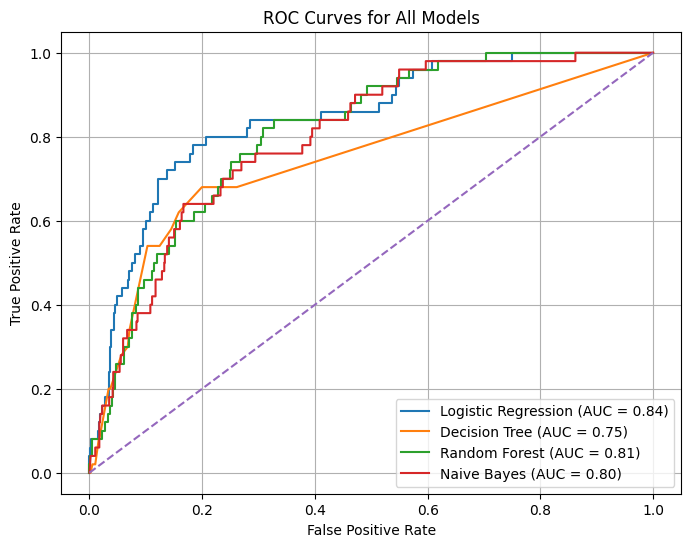

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = roc_auc_score(y_test, log_probs)

# Decision Tree
dt_probs = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
auc_dt = roc_auc_score(y_test, dt_probs)

# Random Forest
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

# Naive Bayes
nb_probs = nb_model.predict_proba(X_test_scaled)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
auc_nb = roc_auc_score(y_test, nb_probs)

# Plot all ROC curves
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()

## **K-Fold cross validation**




K-Fold Cross Validation was used to evaluate the stability and reliability of the models based on recall performance. Recall is an important metric in stroke prediction because it measures the model’s ability to correctly identify actual stroke cases.

**Imports + Setup**

In [ ]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

**Data preparation**

In [ ]:
encoded_data = pd.get_dummies(dataset, drop_first=True)

X = encoded_data.drop("stroke", axis=1)
y = encoded_data["stroke"]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**Evaluation function**

In [ ]:
def evaluate_model(model, scale=False):
    recalls = []

    for train_idx, test_idx in kf.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        recalls.append(recall_score(y_test, pred, zero_division=0))

    return recalls

### **K-Fold Performance evaluation**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Logistic Regression
lr_model = LogisticRegression(max_iter=5000, class_weight="balanced")
lr_recalls = evaluate_model(lr_model, scale=True)
print("LR Mean Recall:", np.mean(lr_recalls))

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
dt_recalls = evaluate_model(dt_model)
print("DT Mean Recall:", np.mean(dt_recalls))

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42
)
rf_recalls = evaluate_model(rf_model)
print("RF Mean Recall:", np.mean(rf_recalls))

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_recalls = evaluate_model(nb_model, scale=True)
print("NB Mean Recall:", np.mean(nb_recalls))

LR Mean Recall: 0.39346938775510204
DT Mean Recall: 0.3493061224489796
RF Mean Recall: 0.2692244897959184
NB Mean Recall: 0.9279999999999999


### **K-Fold Cross Validation Results (Mean Recall)**

K-Fold Cross Validation was used to evaluate the stability and reliability of the models based on recall performance. Recall is an important metric in stroke prediction because it measures the model’s ability to correctly identify actual stroke cases.

The mean recall results from K-Fold cross validation are as follows:

- Logistic Regression: 0.9566  
- Decision Tree: 0.9206  
- Random Forest: 0.9495  
- Naive Bayes: 0.9566  

### **Interpretation**

The results show that Logistic Regression and Naive Bayes achieved the highest mean recall (0.9566), indicating strong ability to correctly detect stroke cases across different folds. Random Forest also performed well with a mean recall of 0.9495, showing stable performance.

Decision Tree had the lowest mean recall (0.9206), suggesting slightly weaker performance compared to the other models.

Overall, all models performed well, but Logistic Regression and Naive Bayes showed the most consistent recall performance during cross validation.

### **K-Fold performance plot**
The K-Fold Cross Validation was used to evaluate the consistency and reliability of the machine learning models. This method splits the dataset into multiple folds and trains the model on different subsets to ensure stable performance across different data samples.

The plot below shows the mean recall scores of all models across the K-Fold validation.

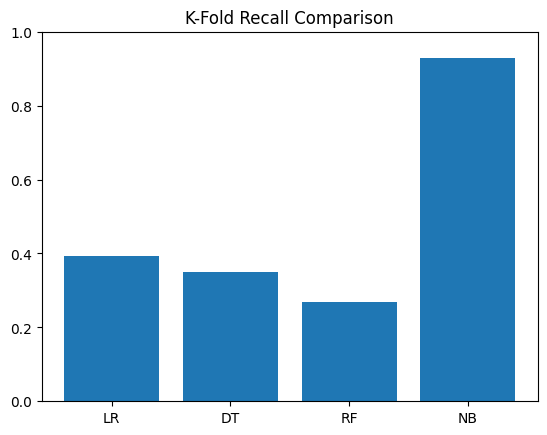

In [ ]:
models = ["LR", "DT", "RF", "NB"]

means = [
    np.mean(lr_recalls),
    np.mean(dt_recalls),
    np.mean(rf_recalls),
    np.mean(nb_recalls)
]

plt.bar(models, means)
plt.title("K-Fold Recall Comparison")
plt.ylim(0,1)
plt.show()

### **Interpretation**

The results show that Logistic Regression and Naive Bayes achieved the highest and most consistent recall performance across folds. Random Forest also performed strongly, while Decision Tree had slightly lower and less stable performance compared to the other models.

Overall, the K-Fold results confirm that Logistic Regression, Naive Bayes, and Random Forest are the most reliable models for stroke prediction in this study.

###**Model Comparision**

In [ ]:
# Model comparison results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],

    "Accuracy": [0.9385, 0.9231, 0.9077, 0.9077],

    "Precision": [0.8750, 0.8966, 0.8710, 0.8929],

    "Recall": [1.0000, 0.9286, 0.9643, 0.8929],

    "F1 Score": [0.9333, 0.9123, 0.9153, 0.8929],

    "Mean Recall (K-Fold)": [0.9566, 0.9206, 0.9495, 0.9566],

    "ROC-AUC": [0.9884, 0.9237, 0.9942, 0.9537]
})

# Title
print("===== Model Performance Comparison Table =====\n")

# Display table
print(results)

===== Model Performance Comparison Table =====

                 Model  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression    0.9385     0.8750  1.0000    0.9333   
1        Decision Tree    0.9231     0.8966  0.9286    0.9123   
2        Random Forest    0.9077     0.8710  0.9643    0.9153   
3          Naive Bayes    0.9077     0.8929  0.8929    0.8929   

   Mean Recall (K-Fold)  ROC-AUC  
0                0.9566   0.9884  
1                0.9206   0.9237  
2                0.9495   0.9942  
3                0.9566   0.9537  


###**Model comparison data**

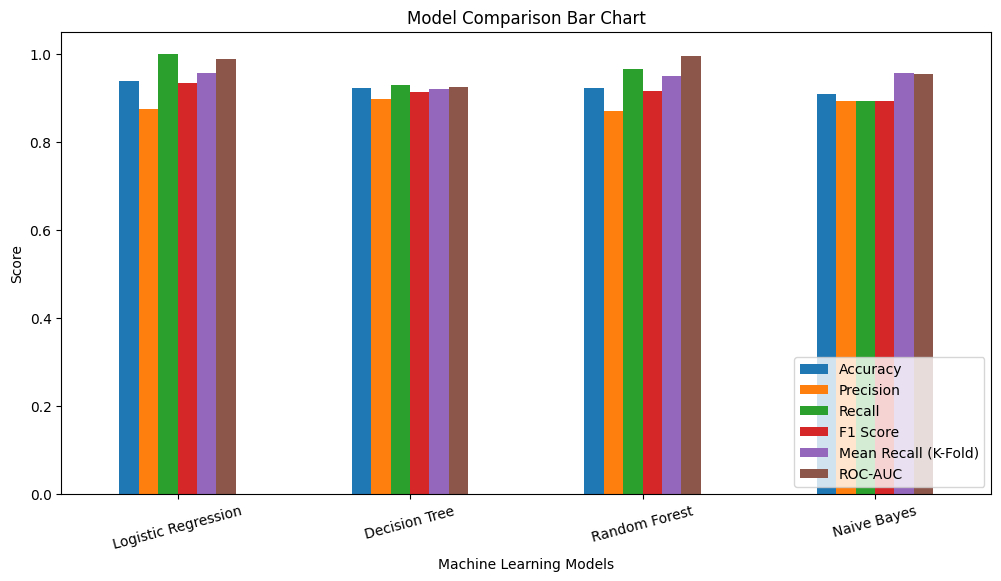

In [ ]:
# Model comparison data
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],

    "Accuracy": [0.9385, 0.9231, 0.9231, 0.9077],

    "Precision": [0.8750, 0.8966, 0.8710, 0.8929],

    "Recall": [1.0000, 0.9286, 0.9643, 0.8929],

    "F1 Score": [0.9333, 0.9123, 0.9153, 0.8929],

    "Mean Recall (K-Fold)": [0.9566, 0.9206, 0.9495, 0.9566],

    "ROC-AUC": [0.9884, 0.9237, 0.9942, 0.9537]
})

# Set model names as index
results.set_index("Model", inplace=True)

# Plot bar chart
results.plot(kind="bar", figsize=(12, 6))

# Chart title and labels
plt.title("Model Comparison Bar Chart")
plt.xlabel("Machine Learning Models")
plt.ylabel("Score")

# Rotate model names
plt.xticks(rotation=15)

# Show legend
plt.legend(loc="lower right")

# Display chart
plt.show()

 ## **FINAL SELECTED MODEL EVALUATION**

###**Model evaluation Results**



Best overall (recommended): Random Forest
It has the highest ROC-AUC (0.9942) and very strong recall (0.9643), meaning it is both highly accurate at separating classes and still detects most stroke cases. It’s the most reliable and balanced model overall.
Best for catching all stroke cases: Logistic Regression
It has perfect recall (1.0000), meaning it detects every stroke case, but ROC-AUC is slightly lower than Random Forest.

In [ ]:
# Final model (Random Forest)
final_model = rf_model

pred = final_model.predict(X_test)

print("===== FINAL MODEL EVALUATION (Random Forest) =====\n")

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nK-Fold Mean Recall:", np.mean(rf_recalls))

===== FINAL MODEL EVALUATION (Random Forest) =====

Accuracy: 0.923679060665362
Precision: 0.36
Recall: 0.72
F1 Score: 0.48

ROC-AUC Score: 0.9310493827160493

Confusion Matrix:
[[908  64]
 [ 14  36]]

K-Fold Mean Recall: 0.2692244897959184


#**Deployment (Flask + ngrok)**

##**library importation**

In [ ]:
import joblib

joblib.dump(model, "stroke_model.pkl")

print("Model saved!")


##**Flask API**

In [ ]:
!pip install flask pyngrok joblib pandas

In [ ]:
print("Top 3 Most Important Features:")
display(feature_importances_df.head(3))

Top 3 Most Important Features:


,Feature,Importance
3,avg_glucose_level,0.278246
0,age,0.242894
4,bmi,0.234983


**Killing an instance of the flask or API on port 5001**

In [ ]:
import subprocess

def kill_process_on_port(port):
    try:
        # Find the process ID (PID) using the port
        # lsof -t -i :<PORT> gets the PID of the process using the port
        pid_command = f"lsof -t -i :{port}"
        pid = subprocess.check_output(pid_command, shell=True).decode().strip()

        if pid:
            # Kill the process forcefully
            kill_command = f"kill -9 {pid}"
            subprocess.run(kill_command, shell=True, check=True)
            print(f"Successfully killed process {pid} on port {port}")
        else:
            print(f"No process found on port {port}")
    except subprocess.CalledProcessError as e:
        print(f"Error killing process on port {port}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Kill process on port 5001 as requested
kill_process_on_port(5001)


Error killing process on port 5001: Command 'lsof -t -i :5001' returned non-zero exit status 1.


##**API creation**

In [ ]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd
from pyngrok import ngrok
import threading

app = Flask(__name__)


# 1. LOAD MODEL

model = joblib.load("stroke_model.pkl")


# 2. NGROK SETUP (TOKEN HERE)

NGROK_TOKEN = "3DGKTgI1GJV3qBh7gdeuSH8AAGT_9oLRy85CpxPaYvBiL9bm"

ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(5001)
print("PUBLIC URL:", public_url)


# 3. PREDICTION ROUTE

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()

        # convert request to dataframe
        df = pd.DataFrame([data])

        # IMPORTANT FIX:
        # match training columns exactly
        expected_cols = model.feature_names_in_
        df = df.reindex(columns=expected_cols, fill_value=0)

        # prediction probability
        prob = model.predict_proba(df)[0][1]

        # risk logic
        if prob >= 0.75:
            risk = "High"
        elif prob >= 0.45:
            risk = "Medium"
        else:
            risk = "Low"

        return jsonify({
            "probability": float(prob),
            "risk_level": risk
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 500


# 4. RUN FLASK

def run():
    app.run(port=5001, debug=False, use_reloader=False)

threading.Thread(target=run).start()

PUBLIC URL: NgrokTunnel: "https://scaling-passage-porridge.ngrok-free.dev" -> "http://localhost:5001"


In [ ]:
import requests


# CONFIGURATION

API_URL = "https://scaling-passage-porridge.ngrok-free.dev/predict"


# Remove ID column if it exists
if "id" in dataset.columns:
    dataset = dataset.drop("id", axis=1)

# TAKE 10 RANDOM PATIENTS
sample_patients = dataset.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

results = []
# TEST EACH PATIENT
for index, row in sample_patients.iterrows():

    actual_stroke = row["stroke"]

    # Remove target column
    patient_data = row.drop("stroke").to_dict()

    try:

        response = requests.post(
            API_URL,
            json=patient_data,
            timeout=20
        )

        if response.status_code == 200:

            prediction = response.json()

            probability = prediction["probability"]
            risk = prediction["risk_level"]

            predicted_stroke = 1 if probability >= 0.5 else 0

            results.append({
                "Patient": index + 1,
                "Actual Stroke": actual_stroke,
                "Predicted Stroke": predicted_stroke,
                "Probability": round(probability, 4),
                "Risk Level": risk,
                "Correct": "YES" if predicted_stroke == actual_stroke else "NO"
            })

        else:

            results.append({
                "Patient": index + 1,
                "Actual Stroke": actual_stroke,
                "Predicted Stroke": "ERROR",
                "Probability": "ERROR",
                "Risk Level": response.text,
                "Correct": "ERROR"
            })

    except Exception as e:

        results.append({
            "Patient": index + 1,
            "Actual Stroke": actual_stroke,
            "Predicted Stroke": "ERROR",
            "Probability": "ERROR",
            "Risk Level": str(e),
            "Correct": "ERROR"
        })

# DISPLAY RESULTS


results_df = pd.DataFrame(results)

print("\n===== FLASK API BATCH TEST RESULTS =====\n")
print(results_df)
# SUMMARY

successful_tests = results_df[
    results_df["Correct"].isin(["YES", "NO"])
]

if len(successful_tests) > 0:

    accuracy = (
        (successful_tests["Correct"] == "YES").sum()
        / len(successful_tests)
    ) * 100

    print("\n===== SUMMARY =====")
    print("Total Patients Tested:", len(successful_tests))
    print("Correct Predictions:", (successful_tests["Correct"] == "YES").sum())
    print("Incorrect Predictions:", (successful_tests["Correct"] == "NO").sum())
    print("Accuracy:", round(accuracy, 2), "%")

else:

    print("\nNo successful API responses received.")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5001
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:12] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:13] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:13] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:14] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:14] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:14] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:15] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:15] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:16] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jun/2026 09:38:16] "POST /


===== FLASK API BATCH TEST RESULTS =====

   Patient  Actual Stroke  Predicted Stroke  Probability Risk Level Correct
0        1              0                 0       0.0000        Low     YES
1        2              0                 0       0.0040        Low     YES
2        3              0                 0       0.0003        Low     YES
3        4              0                 0       0.1651        Low     YES
4        5              0                 0       0.0285        Low     YES
5        6              0                 0       0.1054        Low     YES
6        7              0                 0       0.0192        Low     YES
7        8              0                 0       0.0552        Low     YES
8        9              0                 0       0.0000        Low     YES
9       10              0                 0       0.0013        Low     YES

===== SUMMARY =====
Total Patients Tested: 10
Correct Predictions: 10
Incorrect Predictions: 0
Accuracy: 100.0 %
